In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd

In [49]:
%%time

ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'chembl_valid.csv'),usecols=['smiles'])
display(df)

,smiles
0,CCO
1,C
2,CO
3,NCCS
4,NCCN
...,...
1502534,Cc1cn(C2CN(P(=O)(OCC3CN(P(=O)(OCC4CNCC(n5cnc6c...
1502535,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502536,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502537,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...


CPU times: user 1.01 s, sys: 67.7 ms, total: 1.08 s
Wall time: 1.08 s


In [48]:
# df.to_csv('data/chembl_valid.csv',index=False)

## 1) Get atom counts ...  
Takes 46 secs
in parallel on 14 workers!

In [50]:
df = df.sort_values(by='smiles')
df = df.sort_values(by='smiles',key=lambda x: x.str.len()).reset_index(drop=True)
display(df)

,smiles
0,C
1,CC
2,CO
3,CF
4,CI
...,...
1502534,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502535,Cc1cn(C2CN(P(=O)(OCC3CN(P(=O)(OCC4CNCC(n5cnc6c...
1502536,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502537,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...


In [51]:
%%time
from utilities.rdkit_utils import count_atoms
from pandarallel import pandarallel

pandarallel.initialize(use_memory_fs=False)

df['n_atoms'] = df.smiles.parallel_apply(count_atoms)

INFO: Pandarallel will run on 14 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
CPU times: user 478 ms, sys: 456 ms, total: 934 ms
Wall time: 46.3 s


## Look at histograms ...

In [52]:
display(df)

,smiles,n_atoms
0,C,1
1,CC,2
2,CO,2
3,CF,2
4,CI,2
...,...,...
1502534,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,651
1502535,Cc1cn(C2CN(P(=O)(OCC3CN(P(=O)(OCC4CNCC(n5cnc6c...,678
1502536,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,674
1502537,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,675


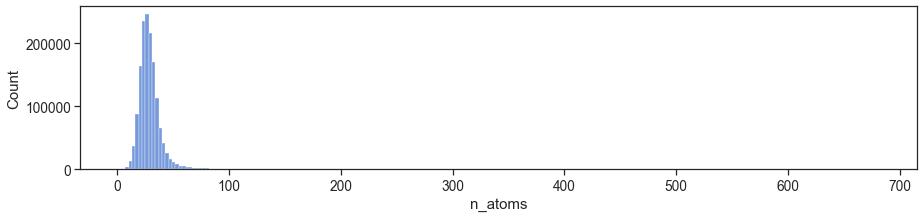

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

plt.figure(figsize=(15,3))
sns.histplot(df, x='n_atoms',binwidth=3)
plt.show()

1501689


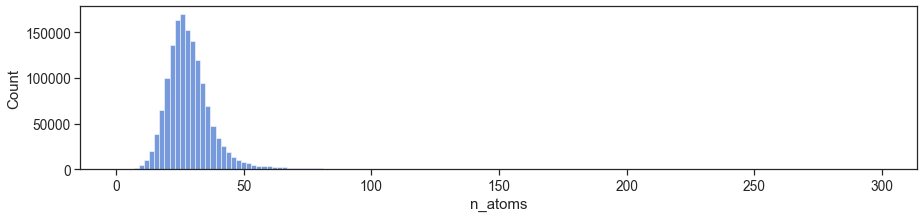

In [54]:
df_trunc300 = df[df.n_atoms < 300]
print(len(df_trunc300))
plt.figure(figsize=(15,3))
sns.histplot(df_trunc300, x='n_atoms',binwidth=2)
plt.show()

1491010


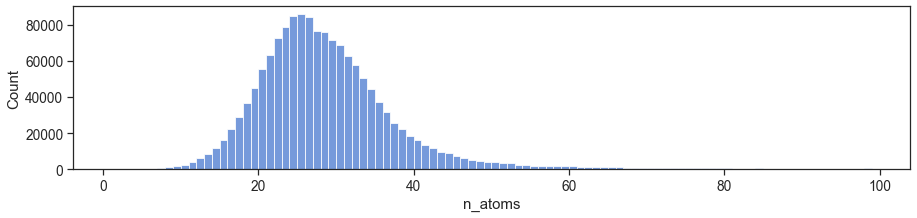

In [55]:
df_trunc100 = df[df.n_atoms < 100]
print(len(df_trunc100))
plt.figure(figsize=(15,3))
sns.histplot(df_trunc100, x='n_atoms',binwidth=1)
plt.show()

1484297


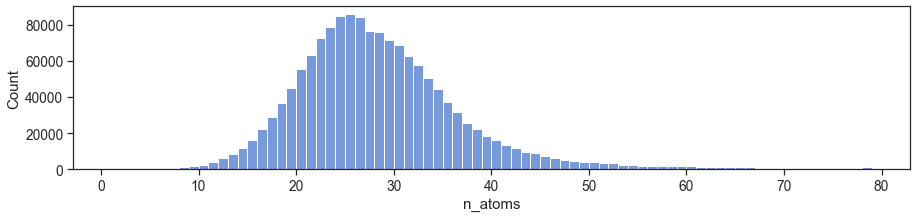

In [56]:
df_trunc80 = df[df.n_atoms < 80]
print(len(df_trunc80))
plt.figure(figsize=(15,3))
sns.histplot(df_trunc80, x='n_atoms',binwidth=1)
plt.show()

999783


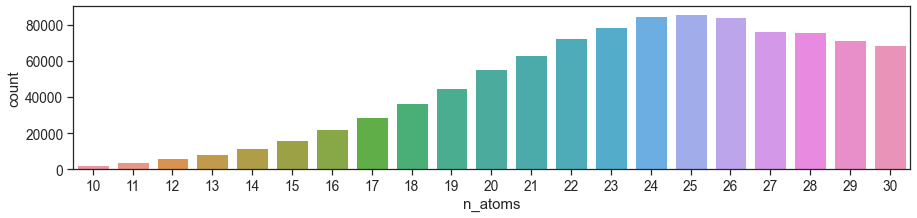

In [57]:
df_mid = df[(df.n_atoms <= 30) & (df.n_atoms >= 10)]
print(len(df_mid))
plt.figure(figsize=(15,3))
sns.countplot(data=df_mid, x='n_atoms')
plt.show()

In [60]:
df_save = df_mid[['smiles']]
df_save.to_csv('data/chembl_valid_10to30atoms.csv',index=False)